In [ ]:
# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# LOAD THE DATASET

# Load Dataset
df = pd.read_csv("customer_churn_dataset-testing-master (1).csv")

# Display First 5 Rows
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [3]:
# DATASET OVERVIEW

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
df.describe()

Dataset Shape:
(64374, 12)

Column Names:
Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  i

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [4]:
#  CHECK MISSING VALUES

print("Missing Values in Dataset:\n")
print(df.isnull().sum())

Missing Values in Dataset:

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [5]:
# CHECK DUPLICATES

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [6]:
# REMOVE UNNECESSARY COLUMN

# Remove CustomerID
df.drop("CustomerID", axis=1, inplace=True)

print("CustomerID column removed successfully.")

CustomerID column removed successfully.


In [7]:
# ENCODE CATEGORICAL VARIABLES

# Create LabelEncoder object
le = LabelEncoder()

# List of categorical columns
categorical_columns = ['Gender', 'Subscription Type', 'Contract Length']

# Apply Label Encoding
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("Categorical Columns Encoded Successfully")

Categorical Columns Encoded Successfully


In [8]:
# DATASET AFTER PREPROCESSING

df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,1,0,757,21,0
3,35,1,9,12,5,17,1,2,232,18,0
4,53,0,58,24,9,2,2,0,533,18,0


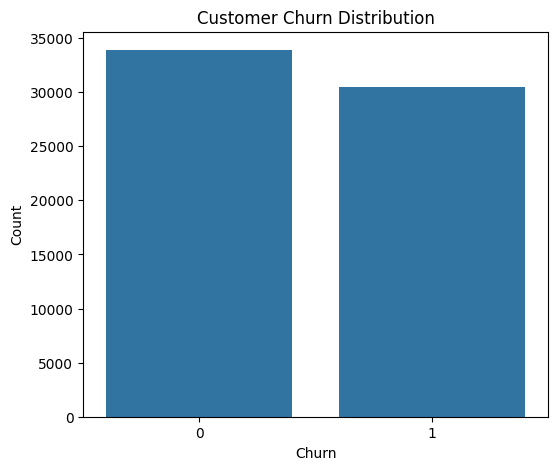

In [9]:
#  VISUALIZATION 1
# CHURN DISTRIBUTION

plt.figure(figsize=(6,5))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

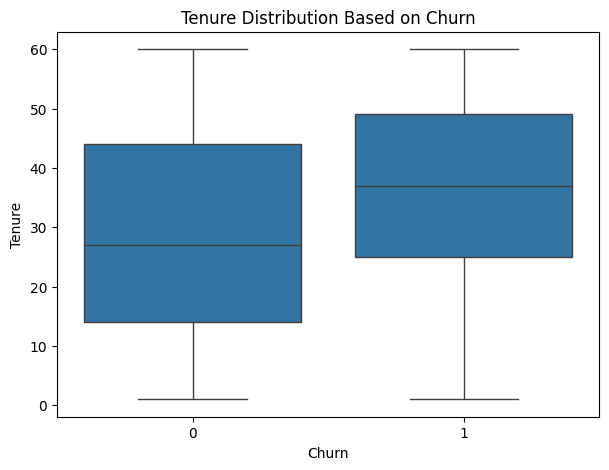

In [10]:
# VISUALIZATION 2
# CONTRACT LENGTH VS CHURN

plt.figure(figsize=(7,5))

sns.boxplot(x='Churn', y='Tenure', data=df)

plt.title("Tenure Distribution Based on Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

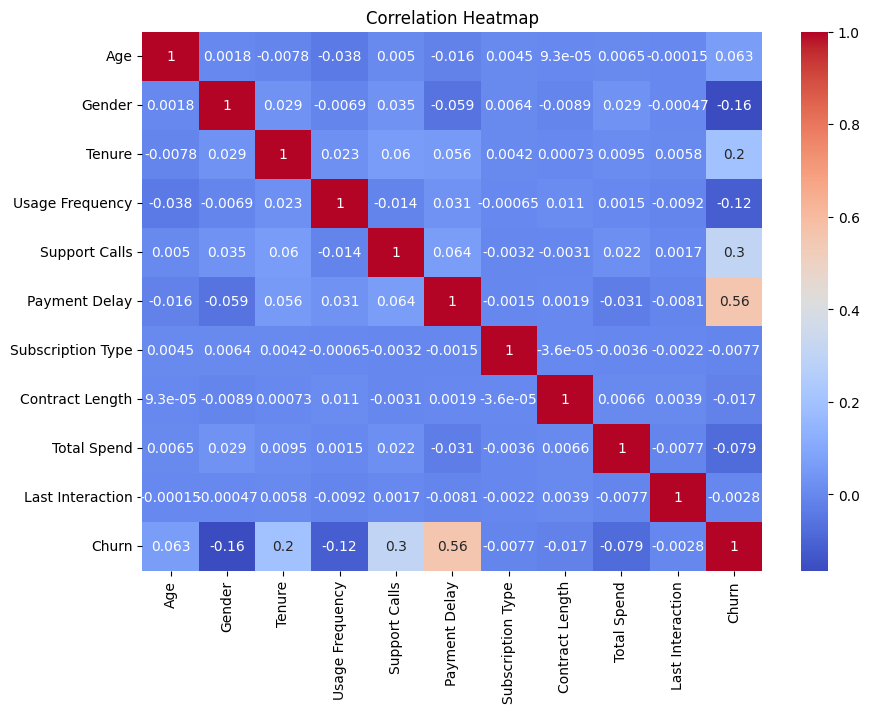

In [11]:
# VISUALIZATION 3
# CORRELATION HEATMAP

plt.figure(figsize=(10,7))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [12]:
# FEATURE SELECTION

# Input Features
X = df.drop("Churn", axis=1)

# Target Variable
y = df["Churn"]

print("Features and Target Variable Created")

Features and Target Variable Created


In [13]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (51499, 10)
Testing Data Shape: (12875, 10)


In [14]:
# FEATURE SCALING

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [15]:
# LOGISTIC REGRESSION MODEL

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [16]:
#  LOGISTIC REGRESSION EVALUATION

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

# Precision
log_precision = precision_score(y_test, y_pred_log)

# Recall
log_recall = recall_score(y_test, y_pred_log)

# F1 Score
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression Performance:\n")

print("Accuracy :", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall   :", round(log_recall, 4))
print("F1-Score :", round(log_f1, 4))

Logistic Regression Performance:

Accuracy : 0.8306
Precision: 0.8141
Recall   : 0.8311
F1-Score : 0.8226


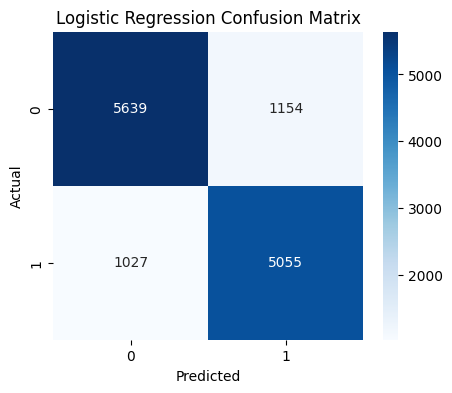

In [ ]:
# CONFUSION MATRIX

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
# CLASSIFICATION REPORT

print("Classification Report:\n")

print(classification_report(y_test, y_pred_log))

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6793
           1       0.81      0.83      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



In [23]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree Model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# Train Model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [ ]:
# DECISION TREE EVALUATION 

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Precision
dt_precision = precision_score(y_test, y_pred_dt)

# Recall
dt_recall = recall_score(y_test, y_pred_dt)

# F1 Score
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance:\n")

print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1-Score :", round(dt_f1, 4))

Decision Tree Performance:

Accuracy : 0.9597
Precision: 0.9355
Recall   : 0.9824
F1-Score : 0.9584


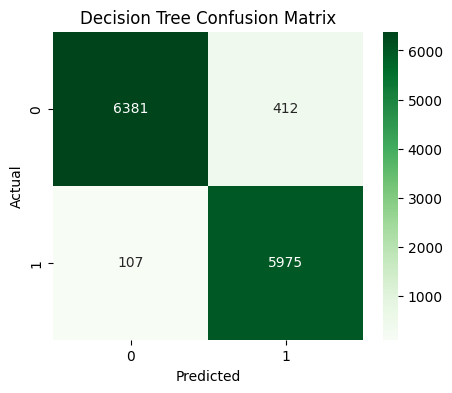

In [ ]:
# CONFUSION MATRIX 

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
# CLASSIFICATION REPORT
print("Classification Report:\n")

print(classification_report(y_test, y_pred_dt))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      6793
           1       0.94      0.98      0.96      6082

    accuracy                           0.96     12875
   macro avg       0.96      0.96      0.96     12875
weighted avg       0.96      0.96      0.96     12875



In [ ]:
#  HYPERPARAMETER TUNING 

parameters = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parameters,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 20}


In [ ]:
#  BEST DECISION TREE MODEL 

best_dt_model = grid_search.best_estimator_

# Predictions
best_dt_pred = best_dt_model.predict(X_test)

# Accuracy
best_dt_accuracy = accuracy_score(y_test, best_dt_pred)

print("Optimized Decision Tree Accuracy:",
      round(best_dt_accuracy, 4))

Optimized Decision Tree Accuracy: 0.99


In [ ]:
# FINAL MODEL COMPARISON 

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [log_accuracy, dt_accuracy],
    'Precision': [log_precision, dt_precision],
    'Recall': [log_recall, dt_recall],
    'F1-Score': [log_f1, dt_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.830602,0.814141,0.831141,0.822553
1,Decision Tree,0.959689,0.935494,0.982407,0.958377


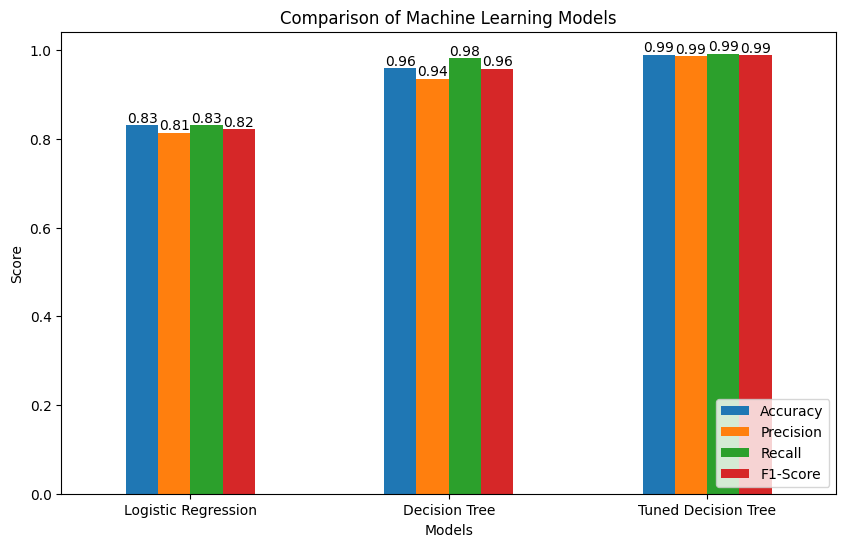

In [39]:
# BAR CHART — MODEL EVALUATION COMPARISON

# Create DataFrame for Model Comparison

model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Tuned Decision Tree'],
    'Accuracy': [log_accuracy, dt_accuracy, best_dt_accuracy],
    'Precision': [log_precision, dt_precision,
                  precision_score(y_test, best_dt_pred)],
    'Recall': [log_recall, dt_recall,
               recall_score(y_test, best_dt_pred)],
    'F1-Score': [log_f1, dt_f1,
                 f1_score(y_test, best_dt_pred)]
})

# Plot graph
ax = model_results.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

# Title and labels
plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")

# Rotate labels
plt.xticks(rotation=0)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

# Show legend
plt.legend(loc='lower right')

# Show plot
plt.show()

In [ ]:
# CELL 26 — FEATURE IMPORTANCE 

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
5,Payment Delay,0.478695
4,Support Calls,0.143954
1,Gender,0.115503
2,Tenure,0.099078
3,Usage Frequency,0.091031
0,Age,0.043059
8,Total Spend,0.021233
7,Contract Length,0.007446
6,Subscription Type,0.000000
9,Last Interaction,0.000000


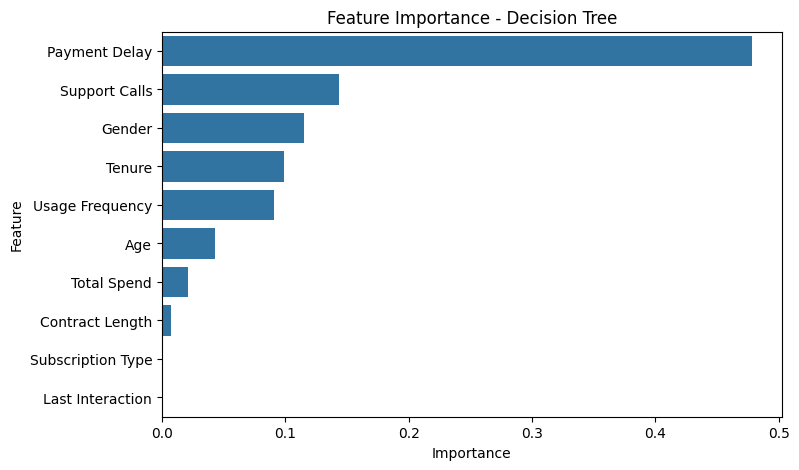

In [ ]:
# CELL 27 — FEATURE IMPORTANCE PLOT 

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance - Decision Tree")

plt.show()